# Random Forest Analysis with Environemnt Variables - Array Level

In [ ]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Geospatial libraries
# ------------------------------------------------------------
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box

# Raster processing
import rasterio
from rasterio.mask import mask

# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Machine learning
# ------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error 

In [51]:
# File paths
# ------------------------------------------------------------
OUTPUT_PATH = "../../outputs"
DATA_PATH = "../../data"

# array-level comparison table
ARRAY_COMPARE_FILE = f"{OUTPUT_PATH}/array_level_ssusa_iucn_comparison.pkl"

# array footprint polygons
ARRAY_FOOTPRINTS_FILE = f"{OUTPUT_PATH}/ssusa_array_footprints_1km.geojson"

# TIGER primary roads
ROADS_FILE = f"{DATA_PATH}/tiger_roads/tl_2025_us_primaryroads.shp"

# NLCD raster
BASE_NLCD_FOLDER = "../../data/nlcd/Annual_NLCD_LndCov_2024_CU_C1V1"
NLCD_FILENAME = "Annual_NLCD_LndCov_2024_CU_C1V1.tif"
NLCD_PATH = f"{BASE_NLCD_FOLDER}/{NLCD_FILENAME}"

# NLCD class groups used in this analysis
FOREST_CLASSES = [41, 42, 43]
GRASS_CLASSES = [71, 72, 73, 74]
WETLAND_CLASSES = [90, 95]
DEVELOPED_CLASSES = [21, 22, 23, 24]
CROP_CLASSES = [81, 82]


In [37]:
# Load array-level table
# ------------------------------------------------------------
array_compare = pd.read_pickle(ARRAY_COMPARE_FILE)
print("array_compare:", array_compare.shape)

# ------------------------------------------------------------
# Load array footprints
# ------------------------------------------------------------
array_fp = gpd.read_file(ARRAY_FOOTPRINTS_FILE)
print("array_fp:", array_fp.shape)

# ------------------------------------------------------------
# Load roads layer
# ------------------------------------------------------------
roads = gpd.read_file(ROADS_FILE)
print("roads:", roads.shape)

array_compare: (261, 14)
array_fp: (261, 4)
roads: (17500, 5)


### Reproject to AEA and compute array centroids

In [38]:
AEA = "EPSG:5070"

# ------------------------------------------------------------
# Reproject array footprints and roads to AEA
# ------------------------------------------------------------
array_fp_aea = array_fp.to_crs(AEA).copy()
roads_aea = roads.to_crs(AEA).copy()

print("Array footprint CRS:", array_fp_aea.crs)
print("Roads CRS:", roads_aea.crs)

# ------------------------------------------------------------
# Compute centroid of each array footprint
# ------------------------------------------------------------
# IMPORTANT:
# Distance to road will be measured from the ARRAY CENTROID,
# not from the full polygon boundary.
array_centroids = array_fp_aea[["Camera_Trap_Array", "geometry"]].copy()
array_centroids["geometry"] = array_centroids.geometry.centroid

print("Number of array centroids:", array_centroids.shape[0])
array_centroids.head()

Array footprint CRS: EPSG:5070
Roads CRS: EPSG:5070
Number of array centroids: 261


,Camera_Trap_Array,geometry
0,ARNWR,POINT (1786956.646 1609117.492)
1,AandM,POINT (-143815.266 353082.619)
2,Abilene,POINT (-364542.936 1025765.325)
3,AbitaFlats,POINT (577424.625 844652.776)
4,Afognak,POINT (-3377244.423 4910273.382)


### Distance from each array centroid to the nearest road

In [39]:
# Union all road geometries into one object
# This makes nearest-distance calculation simpler
# ------------------------------------------------------------
roads_union = roads_aea.geometry.union_all()

# ------------------------------------------------------------
# Compute centroid-to-road distance in meters
# ------------------------------------------------------------
array_centroids["distance_to_road_m"] = array_centroids.geometry.distance(roads_union)

# Keep only needed columns
array_road_dist = array_centroids[
    ["Camera_Trap_Array", "distance_to_road_m"]
].copy()

print("Distance table shape:", array_road_dist.shape)
array_road_dist.head()

Distance table shape: (261, 2)


,Camera_Trap_Array,distance_to_road_m
0,ARNWR,38596.991376
1,AandM,21478.900315
2,Abilene,19857.326265
3,AbitaFlats,13079.279977
4,Afognak,321004.759077


In [40]:
#  Merge centroid-to-road distance into main table
# ============================================================

# Add distance_to_road_m to the main array-level comparison table
array_compare = array_compare.merge(
    array_road_dist,
    on="Camera_Trap_Array",
    how="left"
)

print("array_compare shape after road-distance merge:", array_compare.shape)

# Quick missing-value check
print("\nMissing values in distance_to_road_m:")
print(array_compare["distance_to_road_m"].isna().sum())

array_compare[["Camera_Trap_Array", "distance_to_road_m"]].head()


array_compare shape after road-distance merge: (261, 15)

Missing values in distance_to_road_m:
0


,Camera_Trap_Array,distance_to_road_m
0,ARNWR,38596.991376
1,AandM,21478.900315
2,Abilene,19857.326265
3,AbitaFlats,13079.279977
4,Afognak,321004.759077


### Extract NLCD land-cover percentages for each array footprint

In [60]:
# Open raster once and get CRS / bounds
# ------------------------------------------------------------
with rasterio.open(NLCD_PATH) as src:
    nlcd_crs = src.crs
    raster_bounds = src.bounds

#print("NLCD CRS:", nlcd_crs)
#print("Raster bounds:", raster_bounds)

# Reproject array footprints to raster CRS
array_fp_nlcd = array_fp.to_crs(nlcd_crs).copy()

# Create raster bounds polygon for overlap checks
raster_box = box(*raster_bounds)

# ------------------------------------------------------------
# Helper function to compute grouped percentages for one polygon
# ------------------------------------------------------------
def compute_grouped_nlcd_percentages(geom, src):
    clipped, _ = mask(src, [geom], crop=True, filled=False)
    values = clipped[0].compressed()

    if len(values) == 0:
        return {
            "nlcd_forest_pct": 0.0,
            "nlcd_grass_pct": 0.0,
            "nlcd_wetland_pct": 0.0,
            "nlcd_developed_pct": 0.0,
            "nlcd_crop_pct": 0.0
        }

    total_pixels = len(values)

    return {
        "nlcd_forest_pct": np.isin(values, FOREST_CLASSES).sum() / total_pixels * 100,
        "nlcd_grass_pct": np.isin(values, GRASS_CLASSES).sum() / total_pixels * 100,
        "nlcd_wetland_pct": np.isin(values, WETLAND_CLASSES).sum() / total_pixels * 100,
        "nlcd_developed_pct": np.isin(values, DEVELOPED_CLASSES).sum() / total_pixels * 100,
        "nlcd_crop_pct": np.isin(values, CROP_CLASSES).sum() / total_pixels * 100
    }

# ------------------------------------------------------------
# Loop through all arrays safely
# ------------------------------------------------------------
nlcd_rows = []
failed_arrays = []

with rasterio.open(NLCD_PATH) as src:
    for _, row in array_fp_nlcd.iterrows():
        geom = row.geometry

        # fix invalid geometries if needed
        if geom is not None and not geom.is_valid:
            geom = geom.buffer(0)

        # if still missing/empty, return zeros
        if geom is None or geom.is_empty:
            pct_dict = {
                "nlcd_forest_pct": 0.0,
                "nlcd_grass_pct": 0.0,
                "nlcd_wetland_pct": 0.0,
                "nlcd_developed_pct": 0.0,
                "nlcd_crop_pct": 0.0
            }
            failed_arrays.append((row["Camera_Trap_Array"], "empty geometry"))

        # if polygon does not intersect raster extent, return zeros
        elif not geom.intersects(raster_box):
            pct_dict = {
                "nlcd_forest_pct": 0.0,
                "nlcd_grass_pct": 0.0,
                "nlcd_wetland_pct": 0.0,
                "nlcd_developed_pct": 0.0,
                "nlcd_crop_pct": 0.0
            }
            failed_arrays.append((row["Camera_Trap_Array"], "outside raster extent"))

        else:
            try:
                pct_dict = compute_grouped_nlcd_percentages(geom, src)
            except Exception as e:
                pct_dict = {
                    "nlcd_forest_pct": 0.0,
                    "nlcd_grass_pct": 0.0,
                    "nlcd_wetland_pct": 0.0,
                    "nlcd_developed_pct": 0.0,
                    "nlcd_crop_pct": 0.0
                }
                failed_arrays.append((row["Camera_Trap_Array"], str(e)))

        out_row = {
            "Camera_Trap_Array": row["Camera_Trap_Array"],
            **pct_dict
        }
        nlcd_rows.append(out_row)

nlcd_pct_df = pd.DataFrame(nlcd_rows)

print("NLCD grouped table shape:", nlcd_pct_df.shape)
print("Number of failed arrays:", len(failed_arrays))

nlcd_pct_df.head()

NLCD grouped table shape: (261, 6)
Number of failed arrays: 2


,Camera_Trap_Array,nlcd_forest_pct,nlcd_grass_pct,nlcd_wetland_pct,nlcd_developed_pct,nlcd_crop_pct
0,ARNWR,0.205342,0.263339,83.208979,3.213368,10.328234
1,AandM,0.184162,9.658277,37.159812,1.780233,18.313894
2,Abilene,53.544081,2.465753,4.067439,4.741834,3.231472
3,AbitaFlats,32.858040,0.618779,41.278809,16.133082,8.322124
4,Afognak,0.000000,0.000000,0.000000,0.000000,0.000000


In [61]:
failed_df = pd.DataFrame(failed_arrays, columns=["Camera_Trap_Array", "error"])

print("Failed arrays:")
display(failed_df)

Failed arrays:


,Camera_Trap_Array,error
0,Afognak,outside raster extent
1,Crupi,outside raster extent


In [59]:
nlcd_pct_df.describe()

,nlcd_forest_pct,nlcd_grass_pct,nlcd_wetland_pct,nlcd_developed_pct,nlcd_crop_pct
count,261.000000,261.000000,261.000000,261.000000,261.000000
mean,38.994309,6.284316,9.678372,17.238172,10.942204
std,31.534702,16.510348,16.573420,23.930511,17.010743
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.212638,0.057213,0.111698,2.510362,0.053469
50%,38.786122,0.439693,1.916376,5.846018,2.737382
75%,68.004624,2.958531,11.407046,17.304956,14.615429
max,99.487050,99.113182,83.208979,95.345449,88.971137


In [62]:
# Merge grouped NLCD percentages into main table
# ============================================================

array_compare = array_compare.merge(
    nlcd_pct_df,
    on="Camera_Trap_Array",
    how="left"
)

print("array_compare shape after NLCD merge:", array_compare.shape)

# Check missing values in new NLCD columns
nlcd_cols = [
    "nlcd_forest_pct",
    "nlcd_grass_pct",
    "nlcd_wetland_pct",
    "nlcd_developed_pct",
    "nlcd_crop_pct"
]

print("\nMissing values in NLCD columns:")
print(array_compare[nlcd_cols].isna().sum())

array_compare shape after NLCD merge: (261, 20)

Missing values in NLCD columns:
nlcd_forest_pct       0
nlcd_grass_pct        0
nlcd_wetland_pct      0
nlcd_developed_pct    0
nlcd_crop_pct         0
dtype: int64


In [63]:
# Fill missing NLCD values
# ============================================================

nlcd_cols = [
    "nlcd_forest_pct",
    "nlcd_grass_pct",
    "nlcd_wetland_pct",
    "nlcd_developed_pct",
    "nlcd_crop_pct"
]

array_compare[nlcd_cols] = array_compare[nlcd_cols].fillna(0)

print(array_compare[nlcd_cols].isna().sum())

nlcd_forest_pct       0
nlcd_grass_pct        0
nlcd_wetland_pct      0
nlcd_developed_pct    0
nlcd_crop_pct         0
dtype: int64


In [64]:
array_compare.loc[
    array_compare["Camera_Trap_Array"].isin(["Afognak","Crupi"]),
    [
        "nlcd_forest_pct",
        "nlcd_grass_pct",
        "nlcd_wetland_pct",
        "nlcd_developed_pct",
        "nlcd_crop_pct"
    ]
]

,nlcd_forest_pct,nlcd_grass_pct,nlcd_wetland_pct,nlcd_developed_pct,nlcd_crop_pct
4,0.0,0.0,0.0,0.0,0.0
62,0.0,0.0,0.0,0.0,0.0


### Prepare environment-only RF dataset (X, y)

In [74]:
env_cols = [
    "distance_to_road_m",
    "nlcd_forest_pct",
    "nlcd_grass_pct",
    "nlcd_wetland_pct",
    "nlcd_developed_pct",
    "nlcd_crop_pct"
]

# Predictor matrix
X = array_compare[env_cols].copy()

# Response variable
y = array_compare["jaccard_index"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head(50)

X shape: (261, 6)
y shape: (261,)


,distance_to_road_m,nlcd_forest_pct,nlcd_grass_pct,nlcd_wetland_pct,nlcd_developed_pct,nlcd_crop_pct
0,38596.991376,0.205342,0.263339,83.208979,3.213368,10.328234
1,21478.900315,0.184162,9.658277,37.159812,1.780233,18.313894
2,19857.326265,53.544081,2.465753,4.067439,4.741834,3.231472
3,13079.279977,32.858040,0.618779,41.278809,16.133082,8.322124
4,321004.759077,0.000000,0.000000,0.000000,0.000000,0.000000
5,8167.435750,28.091806,27.751150,5.595104,4.172102,32.289252
6,691.659733,48.296601,1.751540,0.443161,13.161609,34.343634
7,104539.185224,44.804747,0.188584,1.761648,0.602548,0.004600
8,30246.021717,31.542078,0.892429,30.448134,10.430861,15.924575
9,9860.672865,39.091028,0.157300,15.025936,25.874047,19.214996


In [75]:
# Train / Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
# Train Random Forest model
# ============================================================

rf_env = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_env.fit(X_train, y_train)

print("Environment-only Random Forest trained successfully.")

Environment-only Random Forest trained successfully.


In [77]:
# Predict Jaccard similarity on test data
# ============================================================
y_pred_env = rf_env.predict(X_test)

r2 = r2_score(y_test, y_pred_env)
rmse = root_mean_squared_error(y_test, y_pred_env)

print("Environment-only RF performance")
print(f"R²   : {r2:.6f}")
print(f"RMSE : {rmse:.6f}")

Environment-only RF performance
R²   : 0.143631
RMSE : 0.149041


In [78]:

feature_importance_env = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_env.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_env

,feature,importance
5,nlcd_crop_pct,0.208832
0,distance_to_road_m,0.198796
4,nlcd_developed_pct,0.170255
1,nlcd_forest_pct,0.165285
3,nlcd_wetland_pct,0.130494
2,nlcd_grass_pct,0.126339


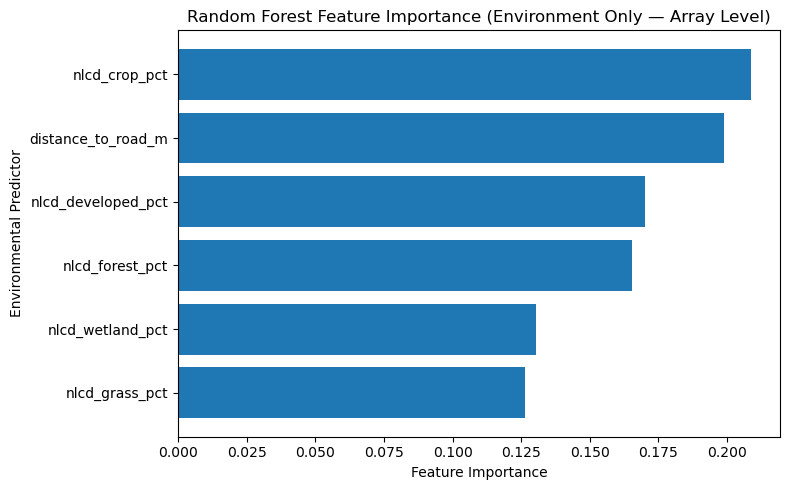

In [80]:
#Sort ascending for horizontal bar plot
fi_plot = feature_importance_env.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_plot["feature"], fi_plot["importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Environmental Predictor")
plt.title("Random Forest Feature Importance (Environment Only — Array Level)")

plt.tight_layout()
plt.show()

### RF Analysis : SSUSA + Environment variabels 

In [81]:
rf_combined = array_compare[
    [
        "jaccard_index",
        "unique_nights_array",
        "habitat_array",
        "development_array",
        "feature_array",
        "distance_to_road_m",
        "nlcd_forest_pct",
        "nlcd_grass_pct",
        "nlcd_wetland_pct",
        "nlcd_developed_pct",
        "nlcd_crop_pct"
    ]
].copy()

# ------------------------------------------------------------
# Clean missing values
# ------------------------------------------------------------
rf_combined["habitat_array"] = rf_combined["habitat_array"].fillna("none")
rf_combined["development_array"] = rf_combined["development_array"].fillna("none")
rf_combined["feature_array"] = rf_combined["feature_array"].fillna("none")

rf_combined["unique_nights_array"] = pd.to_numeric(
    rf_combined["unique_nights_array"],
    errors="coerce"
)
rf_combined["distance_to_road_m"] = pd.to_numeric(
    rf_combined["distance_to_road_m"],
    errors="coerce"
)

# Drop rows missing response or numeric predictors
rf_combined = rf_combined.dropna(
    subset=["jaccard_index", "unique_nights_array", "distance_to_road_m"]
).copy()

print("Combined RF dataframe shape:", rf_combined.shape)

# ------------------------------------------------------------
# One-hot encode categorical SSUSA predictors
# ------------------------------------------------------------
X_cat = pd.get_dummies(
    rf_combined[["habitat_array", "development_array", "feature_array"]],
    prefix=["habitat", "development", "feature"],
    drop_first=False
).astype(int)

# ------------------------------------------------------------
# Keep numeric predictors
# ------------------------------------------------------------
X_num = rf_combined[
    [
        "unique_nights_array",
        "distance_to_road_m",
        "nlcd_forest_pct",
        "nlcd_grass_pct",
        "nlcd_wetland_pct",
        "nlcd_developed_pct",
        "nlcd_crop_pct"
    ]
].copy()

# ------------------------------------------------------------
# Combine all predictors
# ------------------------------------------------------------
X = pd.concat([X_num, X_cat], axis=1)

# Response variable
y = rf_combined["jaccard_index"].copy()

print("Combined X shape:", X.shape)
print("Combined y shape:", y.shape)

X.head()

Combined RF dataframe shape: (261, 11)
Combined X shape: (261, 27)
Combined y shape: (261,)


,unique_nights_array,distance_to_road_m,nlcd_forest_pct,nlcd_grass_pct,nlcd_wetland_pct,nlcd_developed_pct,nlcd_crop_pct,habitat_anthropogenic,habitat_beach,habitat_chaparral,...,development_urban,development_wild,feature_none,feature_other,feature_road dirt,"feature_road dirt, trail hiking",feature_road paved,feature_trail game,feature_trail hiking,feature_water source
0,112,38596.991376,0.205342,0.263339,83.208979,3.213368,10.328234,0,0,0,...,0,1,0,0,1,0,0,0,0,0
1,63,21478.900315,0.184162,9.658277,37.159812,1.780233,18.313894,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,371,19857.326265,53.544081,2.465753,4.067439,4.741834,3.231472,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,85,13079.279977,32.858040,0.618779,41.278809,16.133082,8.322124,0,0,0,...,0,1,1,0,0,0,0,0,0,0
4,35,321004.759077,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,...,0,1,0,0,1,0,0,0,0,0


In [82]:
# Test Train Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (208, 27)
X_test shape : (53, 27)
y_train shape: (208,)
y_test shape : (53,)


In [83]:
# Train combined Random Forest model
# ============================================================

rf_combined_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_combined_model.fit(X_train, y_train)

print("Combined Random Forest trained successfully.")

Combined Random Forest trained successfully.


In [84]:
# Predict Jaccard similarity for unseen test arrays
y_pred_combined = rf_combined_model.predict(X_test)

# Compute test-set performance metrics
r2_combined = r2_score(y_test, y_pred_combined)
rmse_combined = np.sqrt(root_mean_squared_error(y_test, y_pred_combined))

print("Combined RF performance")
print(f"R²   : {r2_combined:.3f}")
print(f"RMSE : {rmse_combined:.3f}")

Combined RF performance
R²   : 0.170
RMSE : 0.383


,feature,importance
6,nlcd_crop_pct,0.181660
1,distance_to_road_m,0.151428
2,nlcd_forest_pct,0.119769
0,unique_nights_array,0.115305
5,nlcd_developed_pct,0.115114
4,nlcd_wetland_pct,0.102147
3,nlcd_grass_pct,0.092982
16,development_suburban,0.014804
11,habitat_forest,0.014065
21,feature_road dirt,0.013835


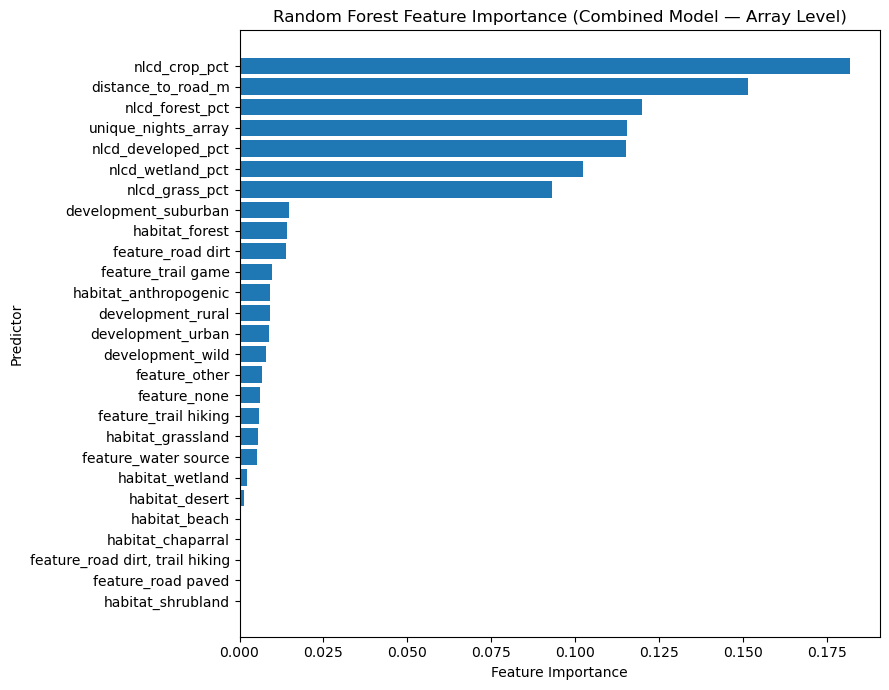

In [85]:
# Create feature-importance table
feature_importance_combined = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_combined_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance_combined.head(20))

# ------------------------------------------------------------
# Plot feature importance
# ------------------------------------------------------------
fi_plot = feature_importance_combined.sort_values("importance", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(fi_plot["feature"], fi_plot["importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Feature Importance (Combined Model — Array Level)")

plt.tight_layout()
plt.show()